# Binary Logistic Regression

This notebook implements Logiestic regression on Tianic survivor dataset 
 

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
titanic = pd.read_csv("/home/karan/ml/lab/3/data/titanic/Titanic_train.csv")
titanic.shape

(891, 12)

In [131]:
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


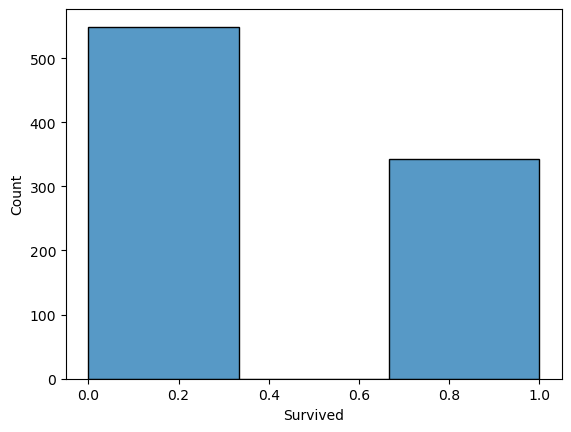

In [132]:
sns.histplot(data=titanic["Survived"], bins=3)
plt.show()

In [133]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Feature Selection

The Outcome is `Survived` ${0,1}$

now we need to select what columns (or Features) to use as predictors

In [134]:
y = titanic["Survived"]
X = titanic.drop(columns=["Survived"])

#### 1. `PassengerId`
contains unique values , not useful.

In [135]:
X = X.drop(columns=["PassengerId"])

#### 2. `Pclass`

Represents the Passenger Class 1, 2 and 3.

It is observed that survival rate in class 3 is low comapred to class 1, maybe because of better facilities provided to VIP class passengers.

`Pclass` is a categorical predictor , so we need to encode it properly

In [136]:
pd.crosstab(titanic["Pclass"], titanic["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [137]:
pd.crosstab(
    titanic["Pclass"],
    titanic["Survived"],
    # divide value by sum of that row
    normalize="index" 
)


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Survival rate in lower class is very less 😥

In [138]:
pclass_dummies = pd.get_dummies(titanic["Pclass"], dtype=int)
pclass_dummies.head()


,1,2,3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1


In [139]:
pclass_dummies.columns = [
    "Pclass_1",
    "Pclass_2",
    "Pclass_3"
]

> We need to drop a column and make it the baseline case, all this to avoid **dummy variable trap** (Perfect Multicollinearity)

In [140]:
# can drop any column , here I am droping the first column and making Class 1 baseline for this encoding
pclass_dummies = pclass_dummies.drop(columns=["Pclass_1"]) 

In [141]:
# concatinating the two df together
X = pd.concat(
    [X.drop(columns=["Pclass"]), pclass_dummies],
    axis=1
)
X

,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3
0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0
2,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0
4,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,0
887,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,1
889,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,0


#### 3. `Name`

useless, drop it

In [142]:
X = X.drop(columns=["Name"])

#### 4. `Sex`

Does Gender affects the survival of passenger ?

In [143]:
pd.crosstab(titanic["Sex"], titanic["Survived"], normalize="index")


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [144]:
sex_dummy = pd.get_dummies(X["Sex"], dtype=int)
sex_dummy = sex_dummy.drop(columns=["female"])
sex_dummy.columns = ["Sex_male"]
X = pd.concat(
    [X.drop(columns=["Sex"]), sex_dummy],
    axis=1
)
X

,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male
0,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,1
1,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0
2,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0
3,35.0,1,0,113803,53.1000,C123,S,0,0,0
4,35.0,0,0,373450,8.0500,NaN,S,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,27.0,0,0,211536,13.0000,NaN,S,1,0,1
887,19.0,0,0,112053,30.0000,B42,S,0,0,0
888,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,1,0
889,26.0,0,0,111369,30.0000,C148,C,0,0,1


#### 5. `Age`

does age affect survival rate ? seems like it does , maybe during rescue childerns were given priority over adults.

In [145]:
X["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

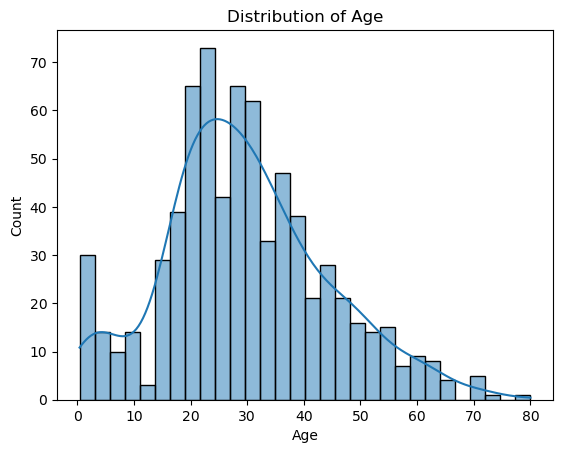

In [146]:
sns.histplot(X["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.show()

seems like most of the passengers were around age 18 ~ 40 , now we need to see age and survival relation. Since `Age` is continuous , we need to break it into categories and then analyse survival rate for each category. 

In [147]:
# Categorize AGE into bins
age_cat = pd.cut(
    X["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# include in the df
titanic["AgeGroup"] = age_cat

# Create a frequency table wrt survival
pd.crosstab(
    titanic["AgeGroup"],
    titanic["Survived"],
    normalize="index"
)

Survived,0,1
AgeGroup,,
Child,0.420290,0.579710
Teen,0.571429,0.428571
YoungAdult,0.617318,0.382682
Adult,0.600000,0.400000
Senior,0.772727,0.227273


/tmp/ipykernel_31804/850518301.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = titanic.groupby("AgeGroup")["Survived"].mean()


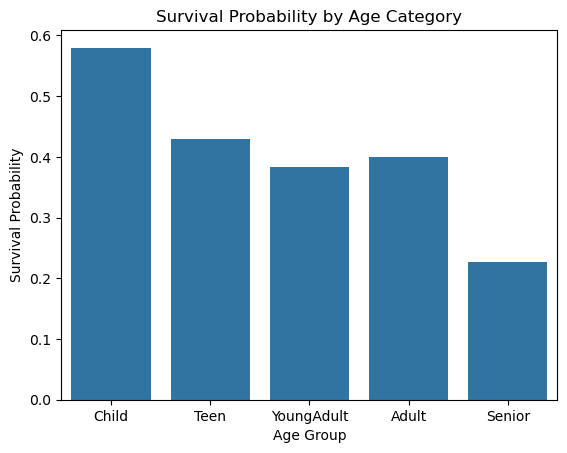

In [148]:
# redundant plot honestly

survival_by_age = titanic.groupby("AgeGroup")["Survived"].mean()

sns.barplot(
    x=survival_by_age.index,
    y=survival_by_age.values
)

plt.ylabel("Survival Probability")
plt.xlabel("Age Group")
plt.title("Survival Probability by Age Category")
plt.show()


now we need to properly enccode all these age groups into our predictors matrix, hmmmmmmmmmmmmmm, lets make the **YoungAdult** baseline for this purpose

In [149]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,YoungAdult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,YoungAdult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,YoungAdult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,YoungAdult


In [150]:
age_dummies = pd.get_dummies(titanic["AgeGroup"], dtype=int)
age_dummies = age_dummies.drop(columns=["YoungAdult"])
age_dummies.head()


,Child,Teen,Adult,Senior
0,0,0,0,0
1,0,0,1,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [151]:
X = pd.concat(
    [X.drop(columns=["Age"]), age_dummies],
    axis=1
)

In [152]:
X

,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,Child,Teen,Adult,Senior
0,1,0,A/5 21171,7.2500,NaN,S,0,1,1,0,0,0,0
1,1,0,PC 17599,71.2833,C85,C,0,0,0,0,0,1,0
2,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0,0,0
3,1,0,113803,53.1000,C123,S,0,0,0,0,0,0,0
4,0,0,373450,8.0500,NaN,S,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0,211536,13.0000,NaN,S,1,0,1,0,0,0,0
887,0,0,112053,30.0000,B42,S,0,0,0,0,0,0,0
888,1,2,W./C. 6607,23.4500,NaN,S,0,1,0,0,0,0,0
889,0,0,111369,30.0000,C148,C,0,0,1,0,0,0,0


#### 6. `SibSp`

Siblings/Spouse , so does having a family increases your survival chances in Titanic ? lets see

In [153]:
titanic["SibSp"].value_counts().sort_index()


SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

hmmmmm, so 0 means the person is traveling alone, 1 mean with some another person (sibling/spouse), >2 means with more persons (multiple spouse ???)

lets see the survival rate for these family sizes

In [154]:
pd.crosstab(
    titanic["SibSp"],
    titanic["Survived"],
    normalize="index"
)

Survived,0,1
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


> dont travel in large gropus, not on Titanic 🥺

lets encode these different family sizes, we will use three categories (Alone, SamllFam, LargeFam) 

In [155]:
def get_famCat(x):
    if x == 0:
        return "Alone"
    elif x <= 2:
        return "SmallFam"
    else:
        return "LargeFam"

X["SibSpGroup"] = X["SibSp"].apply(get_famCat)


In [156]:
# cross checking if label encoding is correct
pd.crosstab(
    X["SibSpGroup"],
    y,
    normalize="index"
)


Survived,0,1
SibSpGroup,,
Alone,0.654605,0.345395
LargeFam,0.847826,0.152174
SmallFam,0.472574,0.527426


In [157]:
sibsp_dummies = pd.get_dummies(X["SibSpGroup"], dtype=int)
sibsp_dummies = sibsp_dummies.drop(columns=["Alone"])
X = pd.concat(
    [X.drop(columns=["SibSp", "SibSpGroup"]), sibsp_dummies],
    axis=1
)

In [158]:
X

,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,Child,Teen,Adult,Senior,LargeFam,SmallFam
0,0,A/5 21171,7.2500,NaN,S,0,1,1,0,0,0,0,0,1
1,0,PC 17599,71.2833,C85,C,0,0,0,0,0,1,0,0,1
2,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0,0,0,0,0
3,0,113803,53.1000,C123,S,0,0,0,0,0,0,0,0,1
4,0,373450,8.0500,NaN,S,0,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,211536,13.0000,NaN,S,1,0,1,0,0,0,0,0,0
887,0,112053,30.0000,B42,S,0,0,0,0,0,0,0,0,0
888,2,W./C. 6607,23.4500,NaN,S,0,1,0,0,0,0,0,0,1
889,0,111369,30.0000,C148,C,0,0,1,0,0,0,0,0,0


#### 7. `Parch`

